<a href="https://colab.research.google.com/github/Rogerio-mack/AD_2026S2/blob/main/Aula_09_Distribuicoes_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guia Rápido de Referência: Funções do `scipy.stats`

| Função SciPy | Nome Matemático | Pergunta do Mundo Real / Interpretação |
| :--- | :--- | :--- |
| **`pmf(k)`** | *Probability Mass Function* | **Discretas:** Qual a probabilidade exata de ocorrer o valor \\(k\\)? (\\(P(X = k)\\)) |
| **`pdf(x)`** | *Probability Density Function* | **Contínuas:** Qual a densidade de probabilidade no ponto \\(x\\)? |
| **`cdf(x)`** | *Cumulative Distribution Function* | Qual a probabilidade acumulada de ser **no máximo** \\(x\\)? (\\(P(X \le x)\\)) |
| **`ppf(q)`** | *Percent Point Function* | Dado um percentil acumulado \\(q\\), qual o valor de corte \\(x\\)? (\\(P(X \le x) = q\\)) |
| **`mean()`** | Valor Esperado \\(E[X]\\) | Qual a média/centro de massa teórico da distribuição? |
| **`var()`** | Variância \\(Var(X)\\) | Qual a dispersão/variabilidade teórica ao redor da média? |
| **`interval(alpha)`**| Intervalo de Confiança | Quais limites \\([a, b]\\) concentram \\(\alpha\%\\) da probabilidade? |
| | | |
| **`sf(x)`** | *Survival Function* | Qual a probabilidade de ser **maior** que \\(x\\)? (\\(1 - CDF = P(X > x)\\)) |
| **`isf(q)`** | *Inverse Survival Function* | Dado o percentil da cauda superior \\(q\\), qual o valor de corte \\(x\\)? (\\(P(X > x) = q\\)) |

# Tabela Resumo das Distribuições para Estudo

| Distribuição | Tipo | Suporte (\\(X\\)) | Parâmetros SciPy | Dica de Identificação em Exercícios |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | Contínua | \\((-\infty, \infty)\\) | `norm(mu,scale)` | Média com \\(\sigma\\) desconhecido e amostra pequena (\\(n<30\\)). |
| | | |  |  |
| **Uniforme Discreta** | Discreta | \\(\{a, a+1, \dots, b\}\\) | `randint(low, high)` | \\(n\\) resultados equiprováveis e contáveis. |
| **Bernoulli** | Discreta | \\(\{0, 1\}\\) | `bernoulli(p)` | Teste único com sucesso (\\(1\\)) ou fracasso (\\(0\\)). |
| **Binomial** | Discreta | \\(\{0, 1, \dots, n\}\\) | `binom(n, p)` | Número de sucessos em \\(n\\) ensaios independentes. |
| **Poisson** | Discreta | \\(\{0, 1, 2, \dots\}\\) | `poisson(mu)` | Ocorrências contadas em intervalo fixo (taxa \\(\lambda\\)). |
| **Geométrica** | Discreta | \\(\{1, 2, 3, \dots\}\\) | `geom(p)` | Número de tentativas até o 1º sucesso. |
| **Exponencial** | Contínua | \\([0, \infty)\\) | `expon(scale=1/lambda)` | Tempo contínuo até a 1ª falha / ocorrência. |
| **Gama** | Contínua | \\([0, \infty)\\) | `gamma(a, scale)` | Tempo contínuo acumulado até a \\(\alpha\\)-ésima falha. |
| **Qui-Quadrada (\\(\chi^2\\))**| Contínua | \\([0, \infty)\\) | `chi2(df)` | Soma de quadrados de Normais; inferência de variância. |
| **Beta** | Contínua | \\(\\) | `beta(a, b)` | Proporções, porcentagens e taxas limitadas em \\(\\). |
| **t-Student** | Contínua | \\((-\infty, \infty)\\) | `t(df)` | Média com \\(\sigma\\) desconhecido e amostra pequena (\\(n<30\\)). |

---

# Distribuição Normal (`scipy.stats.norm`)

A Distribuição Normal (ou Gaussiana) é a mais importante da estatística. Pelo **Teorema do Limite Central**, a soma ou média de um grande número de variáveis aleatórias independentes tende a seguir uma distribuição Normal, independentemente da distribuição original. É caracterizada por sua curva simétrica em formato de sino, definida inteiramente por sua média (\\(\mu\\), parâmetro `loc`) e desvio padrão (\\(\sigma\\), parâmetro `scale`).

#### Cenário / Problema Prático
Um concurso público avaliou os candidatos em uma prova de conhecimentos gerais. As pontuações obtidas seguiram uma distribuição Normal com **média de 70 pontos** (\\(\mu = 70\\)) e **desvio padrão de 10 pontos** (\\(\sigma = 10\\)).

**Perguntas a responder:**
1. Qual a probabilidade de um candidato obter pontuação **entre 60 e 80 pontos** (intervalo de \\(\pm 1\\) desvio padrão em torno da média)?
2. Para obter uma bolsa de estudos integral, o candidato precisa marcar **mais de 85 pontos**. Qual a porcentagem de candidatos elegíveis (\\(P(X > 85)\\))?
3. **Nota de Corte do Exame:** A instituição deseja definir a **nota de corte exata** para **aprovar os 75% melhores candidatos** e reprovar os 25% de menor rendimento. Qual é essa nota?
4. Exiba a média \\(E[X]\\), a variância \\(Var(X) = \sigma^2\\) e o intervalo central de 95% de probabilidade.



In [26]:
def plot_distributions(mu, sigma, x0):

  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from scipy.stats import norm

  # Define os parâmetros da distribuição normal
  # mu = 1.7  # Média
  # sigma = 0.1  # Desvio padrão

  # Gera pontos para o eixo x
  x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

  # Calcula os valores das funções RVS, PDF, CDF e PPF
  rvs_values = norm.rvs(loc=mu, scale=sigma, size=100)
  pdf_values = norm.pdf(x, loc=mu, scale=sigma)
  cdf_values = norm.cdf(x, loc=mu, scale=sigma)

  probabilities = np.linspace(0.001, 0.999, 500) # Evita 0 e 1 para ppf
  ppf_values = norm.ppf(probabilities, loc=mu, scale=sigma)

  # Cria a figura e os subplots
  fig, ax = plt.subplots(1,3,figsize=(12, 4))

  # Gráfico da PDF
  ax[0].plot(x, pdf_values, label='PDF (norm.pdf)')
  sns.kdeplot(rvs_values, label='RVS (norm.rvs)', color='red', lw=1, ax=ax[0])
  ax[0].set_title('Função Densidade de Probabilidade (PDF)')
  ax[0].set_xlabel('Valor (x)')
  ax[0].set_ylabel('Densidade de Probabilidade')
  ax[0].legend(loc='upper left')

  # Gráfico da CDF
  ax[1].plot(x, cdf_values, label='CDF (norm.cdf)', color='orange')
  ax[1].set_title('Função Distribuição Acumulada (CDF)')
  ax[1].set_xlabel('Valor (x)')
  ax[1].set_ylabel('Probabilidade Acumulada')
  ax[1].legend(loc='upper left')

  # Gráfico da PPF
  # Para a PPF, plotamos os quantis (valores x) correspondentes às probabilidades
  ax[2].plot(probabilities, ppf_values, label='PPF (norm.ppf)', color='green')
  ax[2].set_title('Função Quantil (PPF)')
  ax[2].set_xlabel('Probabilidade')
  ax[2].set_ylabel('Quantil (x)')
  ax[2].legend(loc='upper left')

  # x0 = 1.6

  pdf_x0 = norm.pdf(x0, loc=mu, scale=sigma)
  cdf_x0 = norm.cdf(x0, loc=mu, scale=sigma)

  prob_x0 = norm.cdf(x0, loc=mu, scale=sigma)
  ppf_x0 = norm.ppf(prob_x0, loc=mu, scale=sigma)

  ax[0].scatter(x0, pdf_x0, color='darkred', s=100)
  ax[0].axvline(x0, color='darkred', linestyle='-.', lw=0.5)
  ax[0].axhline(pdf_x0, linestyle='-.', lw=0.5, c='darkred')
  ax[0].fill_between(x, pdf_values, where=(x < x0), color='darkred', alpha=0.3)

  ax[1].scatter(x0, cdf_x0, color='darkred', s=100)
  ax[1].axvline(x0, color='darkred', linestyle='-.', lw=0.5)
  ax[1].axhline(cdf_x0, linestyle='-.', lw=0.5, c='darkred')
  # ax[1].fill_between(x, cdf_values, where=(x < x0), color='darkred', alpha=0.3) # não tem significado a área

  ax[2].scatter(prob_x0, ppf_x0, color='darkred', s=100)
  ax[2].axvline(prob_x0, color='darkred', linestyle='-.', lw=0.5)
  ax[2].axhline(ppf_x0, linestyle='-.', lw=0.5, c='darkred')
  # ax[2].fill_between(probabilities, ppf_values, (ax[2].get_ylim()[1] - ax[2].get_ylim()[0])*2, where=(probabilities < prob_x0),  color='darkred', alpha=0.3) # não tem significado a área

  plt.tight_layout()
  plt.show()

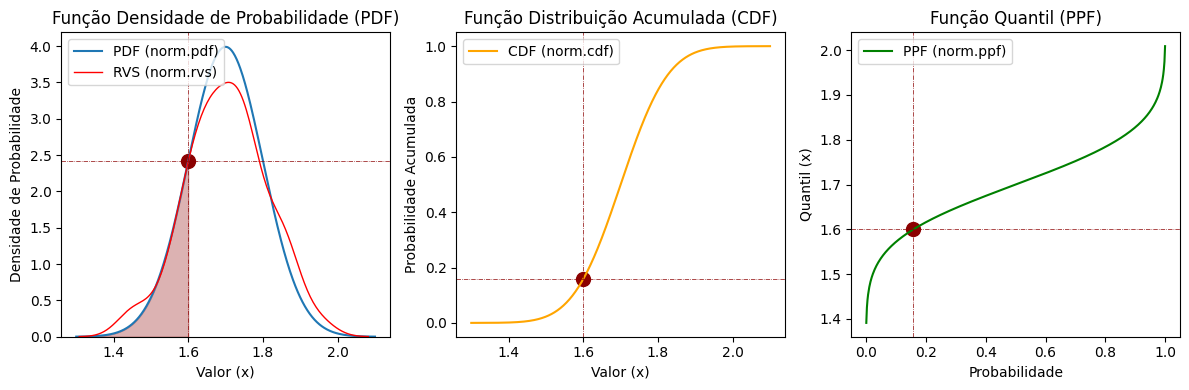

In [27]:
plot_distributions(1.7, 0.1, 1.6)

In [24]:
import scipy.stats as stats

# Parâmetros: loc = mu (média), scale = sigma (desvio padrão)
mu, sigma = 70.0, 10.0
dist_norm = stats.norm(loc=mu, scale=sigma)

# 1. P(60 <= X <= 80) -> CDF(80) - CDF(60)
prob_60_80 = dist_norm.cdf(80) - dist_norm.cdf(60)

# 2. P(X > 85) -> SF (Survival Function)
prob_bolsa = dist_norm.sf(85)

# 3. NOTA DE CORTE PARA APROVAR OS 75% MELHORES CANDIDATOS:
# P(X >= corte) = 0.75 <=> P(X <= corte) = 0.25 -> PPF(0.25)
nota_corte_75_norm = dist_norm.ppf(0.25)

# 4. Média, Variância e Intervalo de 95%
media_norm = dist_norm.mean()
var_norm = dist_norm.var()
intervalo_95_norm = dist_norm.interval(0.95)

print("--- RESULTADOS: DISTRIBUIÇÃO NORMAL ---")
print(
    f"1. P(60 <= X <= 80): {prob_60_80:.4f} ({prob_60_80*100:.2f}%) [Regra"
    " Empírica ~68%]"
)
print(
    f"2. P(Bolsa de Estudos, X > 85): {prob_bolsa:.4f} ({prob_bolsa*100:.2f}%)"
)
print(
    f"3. NOTA DE CORTE EXATA (para 75% melhores): {nota_corte_75_norm:.2f}"
    " pontos"
)
print(
    f"   👉 Candidatos com nota >= {nota_corte_75_norm:.2f} estão APROVADOS!"
)
print(
    f"4. Média E[X] = mu: {media_norm:.1f} | Variância Var(X) = sigma^2:"
    f" {var_norm:.1f}"
)
print(
    "   Intervalo Central de 95% de Probabilidade:"
    f" {intervalo_95_norm[0]:.2f} a {intervalo_95_norm[1]:.2f} pontos"
)


--- RESULTADOS: DISTRIBUIÇÃO NORMAL ---
1. P(60 <= X <= 80): 0.6827 (68.27%) [Regra Empírica ~68%]
2. P(Bolsa de Estudos, X > 85): 0.0668 (6.68%)
3. NOTA DE CORTE EXATA (para 75% melhores): 63.26 pontos
   👉 Candidatos com nota >= 63.26 estão APROVADOS!
4. Média E[X] = mu: 70.0 | Variância Var(X) = sigma^2: 100.0
   Intervalo Central de 95% de Probabilidade: 50.40 a 89.60 pontos


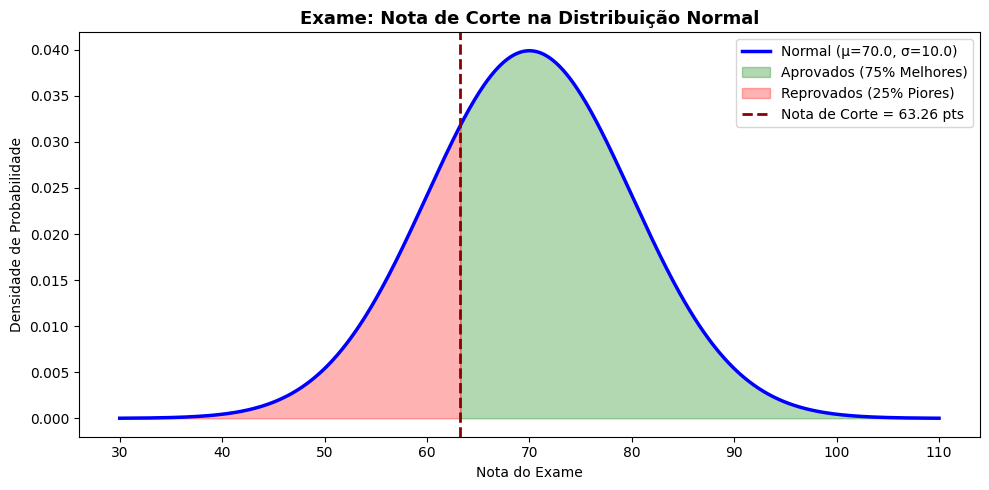

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do gráfico da Normal
x_vals = np.linspace(30, 110, 500)
y_vals = dist_norm.pdf(x_vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, y_vals, "b-", lw=2.5, label=f"Normal (μ={mu}, σ={sigma})")

# Preencher área de aprovação (75% melhores -> x >= nota_corte_75_norm)
x_aprov = np.linspace(nota_corte_75_norm, 110, 300)
ax.fill_between(
    x_aprov,
    dist_norm.pdf(x_aprov),
    color="green",
    alpha=0.3,
    label="Aprovados (75% Melhores)",
)

# Preencher área de reprovação (25% piores -> x < nota_corte_75_norm)
x_reprov = np.linspace(30, nota_corte_75_norm, 200)
ax.fill_between(
    x_reprov,
    dist_norm.pdf(x_reprov),
    color="red",
    alpha=0.3,
    label="Reprovados (25% Piores)",
)

# Linha vertical da Nota de Corte
ax.axvline(
    nota_corte_75_norm,
    color="darkred",
    linestyle="--",
    lw=2,
    label=f"Nota de Corte = {nota_corte_75_norm:.2f} pts",
)

ax.set_title(
    "Exame: Nota de Corte na Distribuição Normal", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Nota do Exame")
ax.set_ylabel("Densidade de Probabilidade")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


# Minha distribuição é normal? (`scipy.stats.probplot`)

Mais adiante poderemos ver testes de hipótese para isso.

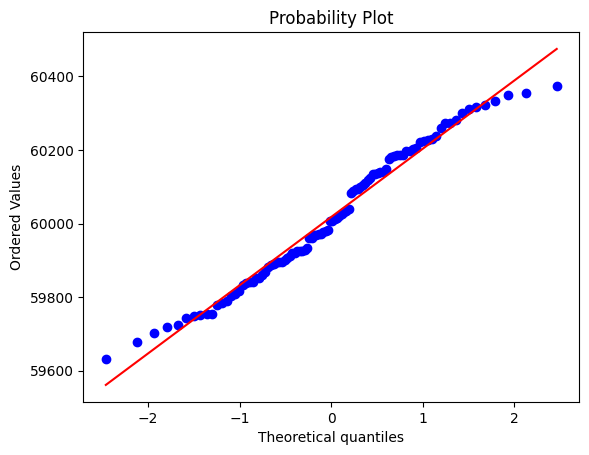

In [29]:
from scipy.stats import probplot

fig, ax = plt.subplots(1,1)

values = stats.norm.rvs(loc=60000, scale=200, size=100)
stats.probplot(values, dist='norm', fit=True, plot=ax)
plt.show()

# PARTE 1: Distribuições Discretas

Nas distribuições discretas, a variável aleatória assume valores contáveis (geralmente inteiros).

### 1. Distribuição Uniforme Discreta (`scipy.stats.randint`)

Ocorre quando um fenômeno possui \\(n\\) resultados possíveis e todos têm **exatamente a mesma probabilidade** de ocorrer. É encontrada em amostragem aleatória simples, sorteios, jogos de azar e auditorias operacionais.

#### Cenário / Problema Prático
Um auditor fiscal precisa inspecionar a documentação de um centro logístico. O galpão possui **50 lotes de mercadorias**, numerados sequencialmente de **1 a 50**. Cada lote tem exatamente a mesma chance de ser sorteado.

**Perguntas a responder:**
1. Qual a probabilidade de o primeiro lote sorteado ser exatamente o **Lote 25**?
2. Qual a probabilidade de o lote sorteado ter número **menor ou igual a 15**?
3. O auditor deseja definir o **lote limite que separa os 75% primeiros lotes** da amostragem (quantil 75%). Qual é esse lote?
4. Calcule a média teórica \\(E[X]\\) e a variância \\(Var(X)\\) dos números dos lotes.



In [1]:
import scipy.stats as stats

# Parâmetros: low=1, high=51 (no scipy, 'high' é exclusivo: lotes de 1 a 50)
dist_unif = stats.randint(low=1, high=51)

# 1. P(X = 25) -> PMF
prob_25 = dist_unif.pmf(25)

# 2. P(X <= 15) -> CDF
prob_ate_15 = dist_unif.cdf(15)

# 3. Percentil 75% (Valor de corte acumulado) -> PPF
lote_75 = dist_unif.ppf(0.75)

# 4. Média e Variância Teóricas
media_unif = dist_unif.mean()
var_unif = dist_unif.var()

print(f"1. P(X = 25): {prob_25:.4f} ({prob_25*100:.2f}%)")
print(f"2. P(X <= 15): {prob_ate_15:.4f} ({prob_ate_15*100:.2f}%)")
print(f"3. Percentil 75%: Lote {int(lote_75)}")
print(f"4. Média E[X]: {media_unif:.2f} | Variância Var(X): {var_unif:.2f}")

1. P(X = 25): 0.0200 (2.00%)
2. P(X <= 15): 0.3000 (30.00%)
3. Percentil 75%: Lote 38
4. Média E[X]: 25.50 | Variância Var(X): 208.25


### 2. Distribuição de Bernoulli (`scipy.stats.bernoulli`)

Modela um **ensaio único** com apenas dois resultados possíveis: "Sucesso" (\\(X = 1\\)) ou "Fracasso" (\\(X = 0\\)), com probabilidade de sucesso igual a \\(p\\). É a base para modelagem de risco de inadimplência, conversão de vendas e testes de diagnóstico.

#### Cenário / Problema Prático
A área de risco de um banco digital analisou um novo cliente solicitante de cartão de crédito. Com base no modelo de Machine Learning do banco, a probabilidade de o cliente ficar inadimplente no primeiro ano é de **\\(p = 0,20\\) (20%)**.

**Perguntas a responder:**
1. Defina a variável \\(X\\) (\\(X=1\\) inadimplente, \\(X=0\\) adimplente) e exiba a probabilidade de cada estado.
2. Calcule o valor esperado \\(E[X]\\) e a variância \\(Var(X)\\) do risco deste cliente.
3. Compare a variância para \\(p=0.20\\) com a variância máxima teórica da Bernoulli (\\(p=0.50\\)).


In [2]:
p_inadimplencia = 0.20
dist_bern = stats.bernoulli(p=p_inadimplencia)

# 1. PMF para X = 0 e X = 1
prob_adimplente = dist_bern.pmf(0)
prob_inadimplente = dist_bern.pmf(1)

# 2. Média e Variância
media_bern = dist_bern.mean()
var_bern = dist_bern.var()

# 3. Variância Máxima (p = 0.50)
var_maxima = stats.bernoulli(p=0.50).var()

print(f"1. P(Adimplente, X=0): {prob_adimplente:.2f} | P(Inadimplente, X=1): {prob_inadimplente:.2f}")
print(f"2. Média E[X] = p = {media_bern:.2f} | Variância Var(X) = p(1-p) = {var_bern:.4f}")
print(f"3. Variância máxima em p=0.50 é {var_maxima:.2f} (maior incerteza).")


1. P(Adimplente, X=0): 0.80 | P(Inadimplente, X=1): 0.20
2. Média E[X] = p = 0.20 | Variância Var(X) = p(1-p) = 0.1600
3. Variância máxima em p=0.50 é 0.25 (maior incerteza).


### 3. Distribuição Binomial (`scipy.stats.binom`)

Representa o número de sucessos em **\\(n\\) ensaios de Bernoulli independentes**, cada um com probabilidade constante \\(p\\). Usada em controle de qualidade industrial, pesquisas de opinião e testes clínicos.

#### Cenário / Problema Prático
Uma fábrica produz microchips com taxa histórica de **5% de peças defeituosas** (\\(p = 0,05\\)). O controle de qualidade inspeciona aleatoriamente um lote de **\\(n = 20\\) microchips**. O lote é aprovado se contiver **no máximo 2 peças defeituosas**.

**Perguntas a responder:**
1. Qual a probabilidade de o lote conter **exatamente 2 peças defeituosas**?
2. Qual a probabilidade de o lote ser **aprovado** (\\(P(X \le 2)\\))?
3. Qual é o **número de defeitos** necessário para colocar o lote entre os **5% piores lotes** (cauda superior)?
4. Calcule o número médio esperado de peças defeituosas por lote (\\(E[X] = n \cdot p\\)).



In [3]:
n_chips, p_defeito = 20, 0.05
dist_binom = stats.binom(n=n_chips, p=p_defeito)

# 1. P(X = 2) -> PMF
prob_exat_2 = dist_binom.pmf(2)

# 2. P(X <= 2) -> CDF (Aprovação)
prob_aprovacao = dist_binom.cdf(2)

# 3. Quantidade de defeitos dos 5% piores lotes (PPF 95%)
corte_piores_5 = dist_binom.ppf(0.95)

# 4. Média e Variância
media_binom = dist_binom.mean()
var_binom = dist_binom.var()

print(f"1. P(Exatamente 2 defeituosos): {prob_exat_2:.4f} ({prob_exat_2*100:.2f}%)")
print(f"2. P(Lote Aprovado, X <= 2): {prob_aprovacao:.4f} ({prob_aprovacao*100:.2f}%)")
print(f"3. Limiar dos 5% piores lotes: >= {int(corte_piores_5)} peças defeituosas")
print(f"4. Média E[X] = n*p: {media_binom:.2f} peças | Variância Var(X): {var_binom:.4f}")


1. P(Exatamente 2 defeituosos): 0.1887 (18.87%)
2. P(Lote Aprovado, X <= 2): 0.9245 (92.45%)
3. Limiar dos 5% piores lotes: >= 3 peças defeituosas
4. Média E[X] = n*p: 1.00 peças | Variância Var(X): 0.9500


### 4. Distribuição de Poisson (`scipy.stats.poisson`)

Modela o número de ocorrências de um evento em um **intervalo contínuo fixo** (tempo, área ou volume), com taxa média constante \\(\lambda\\). Usada em dimensionamento de servidores, filas de atendimento e acidentes de trânsito.

#### Cenário / Problema Prático
Um servidor de e-commerce recebe em média **\\(\lambda = 12\\) requisições por segundo** no horário de pico.

**Perguntas a responder:**
1. Qual a probabilidade de o servidor receber **exatamente 10 requisições** em um segundo?
2. O servidor entra em risco de lentidão se receber **mais de 15 requisições/segundo**. Qual a probabilidade de sobrecarga (\\(P(X > 15)\\))?
3. Qual deve ser a **capacidade mínima de processamento/segundo** do servidor para suportar **99% da demanda sem cair**?
4. Verifique a propriedade teórica de que \\(E[X] = Var(X) = \lambda\\).



In [5]:
lam = 12.0
dist_poisson = stats.poisson(mu=lam)

# 1. P(X = 10) -> PMF
prob_10_req = dist_poisson.pmf(10)

# 2. P(X > 15) -> Survival Function (SF = 1 - CDF)
prob_sobrecarga = dist_poisson.sf(15)

# 3. Capacidade mínima para 99% de garantia -> PPF(0.99)
capacidade_99 = dist_poisson.ppf(0.99)

# 4. Média e Variância
media_poisson = dist_poisson.mean()
var_poisson = dist_poisson.var()

print(f"1. P(Exatamente 10 req/s): {prob_10_req:.4f} ({prob_10_req*100:.2f}%)")
print(f"2. P(Sobrecarga > 15 req/s): {prob_sobrecarga:.4f} ({prob_sobrecarga*100:.2f}%)")
print(f"3. Capacidade recomendada (99% de garantia): {int(capacidade_99)} req/s")
print(f"4. Média E[X] = {media_poisson:.1f} | Variância Var(X) = {var_poisson:.1f} (Ambas iguais a lambda={lam})")


1. P(Exatamente 10 req/s): 0.1048 (10.48%)
2. P(Sobrecarga > 15 req/s): 0.1556 (15.56%)
3. Capacidade recomendada (99% de garantia): 21 req/s
4. Média E[X] = 12.0 | Variância Var(X) = 12.0 (Ambas iguais a lambda=12.0)


### 5. Distribuição Geométrica (`scipy.stats.geom`)

Modela o **número de ensaios de Bernoulli necessários até obter o primeiro sucesso**. Possui a propriedade da **"Falta de Memória"**. Aplicada em prospecção de vendas, testes de resistência por impacto e tentativas de reconexão de rede.

#### Cenário / Problema Prático
Um vendedor B2B tem taxa de conversão de **\\(p = 0,15\\) (15%)** por chamada telefônica realizada.

**Perguntas a responder:**
1. Qual a probabilidade de fechar a primeira reunião **exatamente na 4ª abordagem**?
2. Qual a probabilidade de precisar de **mais de 5 abordagens** (\\(P(X > 5)\\))?
3. Quantas abordagens planejar para ter **90% de certeza acumulada** de conseguir ao menos uma venda?
4. Calcule o número médio esperado de abordagens necessárias (\\(E[X] = 1/p\\)).



In [6]:
p_venda = 0.15
dist_geom = stats.geom(p=p_venda)

# 1. P(X = 4) -> PMF
prob_4_tentativa = dist_geom.pmf(4)

# 2. P(X > 5) -> SF
prob_mais_5 = dist_geom.sf(5)

# 3. Abordagens para 90% de certeza acumulada -> PPF(0.90)
tentativas_90 = dist_geom.ppf(0.90)

# 4. Média e Variância
media_geom = dist_geom.mean()
var_geom = dist_geom.var()

print(f"1. P(Primeira venda na 4ª chamada): {prob_4_tentativa:.4f} ({prob_4_tentativa*100:.2f}%)")
print(f"2. P(Precisar de mais de 5 chamadas): {prob_mais_5:.4f} ({prob_mais_5*100:.2f}%)")
print(f"3. Chamadas necessárias para 90% de garantia: {int(tentativas_90)} abordagens")
print(f"4. Média Esperada E[X] = 1/p: {media_geom:.2f} abordagens | Variância: {var_geom:.2f}")


1. P(Primeira venda na 4ª chamada): 0.0921 (9.21%)
2. P(Precisar de mais de 5 chamadas): 0.4437 (44.37%)
3. Chamadas necessárias para 90% de garantia: 15 abordagens
4. Média Esperada E[X] = 1/p: 6.67 abordagens | Variância: 37.78


# PARTE 2: Distribuições Contínuas

Nas distribuições contínuas, a variável aleatória pode assumir qualquer valor em um intervalo contínuo. A probabilidade em um ponto exato é zero ($P(X = x) = 0$), de modo que trabalhamos com a Função Densidade de Probabilidade (pdf) e probabilidades em intervalos por meio da Função Acumulada (cdf).

### 6. Distribuição Exponencial (`scipy.stats.expon`)

A Distribuição Exponencial modela o **tempo contínuo decorrido entre eventos de um processo de Poisson** (ex: tempo até a falha de um componente ou tempo de espera na fila). No `scipy.stats.expon`, o parâmetro `scale` equivale à média de vida útil \\(1/\lambda\\).

#### Cenário / Problema Prático
O departamento de engenharia de qualidade de uma montadora testa sensores de pressão industrial. O tempo de vida útil de um sensor até a primeira falha segue uma distribuição Exponencial com **vida média de 10 meses** (`scale = 10.0`).

**Perguntas a responder:**
1. Qual a probabilidade de um sensor **falhar nos primeiros 6 meses** de operação (\\(P(X \le 6)\\))?
2. A fábrica deseja oferecer uma garantia de substituição gratuita. Qual deve ser o **prazo de garantia (em meses)** para que no máximo **5% dos sensores apresentem defeito** e precisem ser trocados dentro do prazo?
3. Calcule o tempo médio de vida útil \\(E[X]\\) e o intervalo central que abrange 90% da vida útil dos sensores.



In [11]:
import scipy.stats as stats

# Parâmetro scale = 1/lambda = 10.0 meses
media_vida = 10.0
dist_expon = stats.expon(scale=media_vida)

# 1. P(X <= 6) -> CDF
prob_falha_6m = dist_expon.cdf(6)

# 2. Prazo de garantia para no máximo 5% de trocas -> PPF(0.05)
prazo_garantia_5 = dist_expon.ppf(0.05)

# 3. Média e Intervalo Central de 90%
media_exp = dist_expon.mean()
var_exp = dist_expon.var()
intervalo_90_exp = dist_expon.interval(0.90)

print("--- RESULTADOS: EXPONENCIAL ---")
print(f"1. P(Falhar nos primeiros 6 meses): {prob_falha_6m:.4f} ({prob_falha_6m*100:.2f}%)")
print(f"2. PRAZO DE GARANTIA RECOMENDADO: {prazo_garantia_5:.2f} meses (~{int(prazo_garantia_5*30)} dias)")
print(f"3. Média Teórica E[X]: {media_exp:.1f} meses | Variância: {var_exp:.1f}")
print(f"   Intervalo Central de 90% de Vida Útil: {intervalo_90_exp[0]:.2f} a {intervalo_90_exp[1]:.2f} meses")



--- RESULTADOS: EXPONENCIAL ---
1. P(Falhar nos primeiros 6 meses): 0.4512 (45.12%)
2. PRAZO DE GARANTIA RECOMENDADO: 0.51 meses (~15 dias)
3. Média Teórica E[X]: 10.0 meses | Variância: 100.0
   Intervalo Central de 90% de Vida Útil: 0.51 a 29.96 meses


### 7. Distribuição Gama (`scipy.stats.gamma`)

A Distribuição Gama é uma generalização da Exponencial. Modela o **tempo contínuo acumulado até a ocorrência de \\(\alpha\\) (ou \\(k\\)) eventos independentes de Poisson**. É usada em análise de sobrevivência, engenharia de confiabilidade de máquinas com sistemas de redundância.

#### Cenário / Problema Prático
Um servidor de missão crítica em um datacenter possui **3 sistemas de energia redundantes** (\\(\alpha = 3\\)). Cada sistema tem um tempo médio de operação contínua até falha de **2 anos** (`scale = 2.0`). O servidor só cai quando todos os 3 sistemas falham sequencialmente.

**Perguntas a responder:**
1. Qual a probabilidade de o servidor completo continuar funcionando por **mais de 8 anos** (\\(P(X > 8)\\))?
2. Qual o tempo de operação em que **90% dos datacenters** ainda estarão com o servidor funcionando perfeitamente?
3. Calcule o tempo médio esperado de operação total do servidor (\\(E[X] = \alpha \cdot \text{scale}\\)).


In [13]:
# Parâmetros: alpha = 3 (número de falhas), scale = 2.0 anos
alpha = 3
scale_gama = 2.0
dist_gamma = stats.gamma(a=alpha, scale=scale_gama)

# 1. P(X > 8) -> SF (Survival Function)
prob_mais_8anos = dist_gamma.sf(8)

# 2. Tempo garantido com 90% de confiabilidade -> PPF(0.10)
tempo_90_confianca = dist_gamma.ppf(0.10)

# 3. Média, Variância e Intervalo de 95%
media_gamma = dist_gamma.mean()
var_gamma = dist_gamma.var()
intervalo_95_gamma = dist_gamma.interval(0.95)

print("--- RESULTADOS: GAMA ---")
print(f"1. P(Servidor durar mais de 8 anos): {prob_mais_8anos:.4f} ({prob_mais_8anos*100:.2f}%)")
print(f"2. Tempo com 90% dos servidores operacionais: {tempo_90_confianca:.2f} anos")
print(f"3. Média Esperada E[X] = a * scale: {media_gamma:.2f} anos | Variância: {var_gamma:.2f}")
print(f"   Intervalo de 95% de expectativa operacional: {intervalo_95_gamma[0]:.2f} a {intervalo_95_gamma[1]:.2f} anos")


--- RESULTADOS: GAMA ---
1. P(Servidor durar mais de 8 anos): 0.2381 (23.81%)
2. Tempo com 90% dos servidores operacionais: 2.20 anos
3. Média Esperada E[X] = a * scale: 6.00 anos | Variância: 12.00
   Intervalo de 95% de expectativa operacional: 1.24 a 14.45 anos


### 8. Distribuição Qui-Quadrada (\\(\chi^2\\)) (`scipy.stats.chi2`)

A Distribuição Qui-Quadrada surge da soma dos quadrados de \\(k\\) variáveis aleatórias Normais Padrão independentes (onde \\(k = df\\) é o número de graus de liberdade). É a base para a inferência sobre **variâncias amostrais** e para os **testes de aderência e independência qui-quadrada**.

#### Cenário / Problema Prático
Em um processo de envase automático de sacos de café de 500g, o controle de qualidade extrai amostras de tamanho \\(n = 16\\) para avaliar a variabilidade da máquina. Sob a hipótese de estabilidade, a estatística de teste calculada segue uma distribuição Qui-Quadrada com **\\(df = k = 15\\) graus de liberdade**.

**Perguntas a responder:**
1. Qual a probabilidade de a estatística de teste resultar em um valor **maior que 25,0** (\\(P(\chi^2 > 25,0)\\))?
2. Qual é o **valor crítico \\(\chi^2_{crit}\\)** para um teste de hipóteses com nível de significância de \\(\alpha = 0,05\\) (5% na cauda superior)?
3. Verifique a propriedade teórica de que a média é igual aos graus de liberdade (\\(E[\chi^2] = df\\)) e a variância é igual ao dobro deles (\\(Var(\chi^2) = 2 \cdot df\\)).



In [15]:
df_k = 15
dist_chi2 = stats.chi2(df=df_k)

# 1. P(Chi2 > 25.0) -> SF (P-valor da cauda superior)
prob_maior_25 = dist_chi2.sf(25.0)

# 2. Valor Crítico para alpha = 0.05 na cauda superior -> ISF(0.05)
k_critico = dist_chi2.isf(0.05)

# 3. Média e Variância
media_chi2 = dist_chi2.mean()
var_chi2 = dist_chi2.var()
intervalo_95_chi2 = dist_chi2.interval(0.95)

print("--- RESULTADOS: QUI-QUADRADA ---")
print(f"1. P(Chi2 > 25.0) [P-valor de cauda]: {prob_maior_25:.4f} ({prob_maior_25*100:.2f}%)")
print(f"2. VALOR CRÍTICO k_crit (para alpha = 0.05): {k_critico:.4f}")
print(f"3. Média E[X] = df = {media_chi2:.1f} | Variância Var(X) = 2*df = {var_chi2:.1f}")
print(f"   Intervalo Central de 95%: {intervalo_95_chi2[0]:.2f} a {intervalo_95_chi2[1]:.2f}")



--- RESULTADOS: QUI-QUADRADA ---
1. P(Chi2 > 25.0) [P-valor de cauda]: 0.0499 (4.99%)
2. VALOR CRÍTICO k_crit (para alpha = 0.05): 24.9958
3. Média E[X] = df = 15.0 | Variância Var(X) = 2*df = 30.0
   Intervalo Central de 95%: 6.26 a 27.49


### 9. Distribuição Beta (`scipy.stats.beta`)

A Distribuição Beta é definida estritamente no intervalo limitado \\(\\), tornando-a o modelo ideal para representar **proporções, porcentagens, probabilidades e taxas de conversão**. É muito utilizada em estatística bayesiana como distribuição *prior* conjugada para parâmetros de proporção.

#### Cenário / Problema Prático
O time de Data Science de um e-commerce analisa a taxa de conversão (CTR) de uma nova página de checkout. Com base nos testes A/B anteriores, a taxa de conversão é modelada por uma distribuição Beta com parâmetros de forma **\\(\alpha = 5\\)** e **\\(\beta = 20\\)**.

**Perguntas a responder:**
1. Qual é a **densidade de probabilidade (`pdf`)** no ponto de 20% de conversão (\\(x = 0,20\\))?
2. Qual a probabilidade de a verdadeira taxa de conversão da página ser **superior a 25%** (\\(P(X > 0,25)\\))?
3. Qual é a taxa de conversão referente ao **percentil 75%**?
4. Calcule a média esperada da taxa de conversão \\(E[X] = \alpha / (\alpha + \beta)\\) e seu intervalo de credibilidade de 90%.



In [17]:
a_param, b_param = 5, 20
dist_beta = stats.beta(a=a_param, b=b_param)

# 1. PDF no ponto x = 0.20
densidade_20 = dist_beta.pdf(0.20)

# 2. P(X > 0.25) -> SF
prob_maior_25p = dist_beta.sf(0.25)

# 3. Percentil 75% -> PPF(0.75)
perc_75 = dist_beta.ppf(0.75)

# 4. Média Teórica e Intervalo de Credibilidade de 90%
media_beta = dist_beta.mean()
var_beta = dist_beta.var()
intervalo_90_beta = dist_beta.interval(0.90)

print("--- RESULTADOS: BETA ---")
print(f"1. Densidade de Probabilidade f(0.20): {densidade_20:.4f}")
print(f"2. P(Taxa de Conversão > 25%): {prob_maior_25p:.4f} ({prob_maior_25p*100:.2f}%)")
print(f"3. Taxa de conversão no percentil 75%: {perc_75*100:.2f}%")
print(f"4. Média Teórica E[X] = a / (a+b): {media_beta*100:.2f}% | Variância: {var_beta:.6f}")
print(f"   Intervalo de Credibilidade de 90%: {intervalo_90_beta[0]*100:.2f}% a {intervalo_90_beta[1]*100:.2f}%")


--- RESULTADOS: BETA ---
1. Densidade de Probabilidade f(0.20): 4.9004
2. P(Taxa de Conversão > 25%): 0.2466 (24.66%)
3. Taxa de conversão no percentil 75%: 24.90%
4. Média Teórica E[X] = a / (a+b): 20.00% | Variância: 0.006154
   Intervalo de Credibilidade de 90%: 8.59% a 34.18%


### 10. Distribuição t-Student e o Problema Clássico da Nota de Corte (`scipy.stats.t`)

A Distribuição t-Student é utilizada quando estimamos a média de uma população normalmente distribuída, mas o **desvio padrão populacional é desconhecido** e o tamanho da amostra \\(n\\) é pequeno. Possui caudas mais pesadas (*leptocúrtica*) que a Normal Padrão para compensar a incerteza da amostragem.

À medida que os graus de liberdade (\\(df = n - 1\\)) aumentam, a t-Student **converge assintoticamente para a Distribuição Normal Padrão** \\(Z \sim \mathcal{N}(0, 1)\\).

#### Cenário / Problema Prático Clássico: Definição da Nota de Corte do Exame
Uma instituição aplicou um exame simulado altamente rigoroso para uma amostra piloto de **\\(n = 10\\) estudantes** (\\(df = n - 1 = 9\\)). As notas foram padronizadas em escore t. A coordenação pedagógica decidiu que deseja **aprovar exatamente os 75% melhores candidatos** e reprovar os 25% de menor rendimento.

**Perguntas a responder:**
1. **Definição da Nota de Corte:** Qual é a pontuação padronizada exata de corte \\(x_{corte}\\) para que **75% dos candidatos fiquem acima dela** (\\(P(X \ge x_{corte}) = 0,75\\))? *(Isso equivale ao acumulado de 25% na PPF, ou 0.75 na ISF)*.
2. Calcule o intervalo central de 95% de confiança para as notas padronizadas nesta distribuição com \\(df = 9\\).
3. **Demonstração Numérica da Convergência:** Calcule o quantil 97.5% (\\(t_{0.975}\\)) para \\(df \in\\) e compare com o valor limite \\(Z_{0.975} = 1,9600\\) da Normal Padrão.



In [22]:
n_amostra = 10
df_exame = n_amostra - 1  # df = 9
dist_t = stats.t(df=df_exame)

# 1. NOTA DE CORTE PARA APROVAR OS 75% MELHORES CANDIDATOS:
# P(X >= corte) = 0.75 <=> P(X <= corte) = 0.25 (PPF em 0.25)
nota_corte_75 = dist_t.ppf(0.25)

# 2. Intervalo Central de 95% de Confiança
intervalo_95_t = dist_t.interval(0.95)

print("--- RESULTADOS: t-STUDENT E NOTA DE CORTE ---")
print(f"1. NOTA DE CORTE EXATA (para aprovar os 75% melhores): {nota_corte_75:.4f}")
print(f"   👉 Interpretação: Candidatos com nota padronizada >= {nota_corte_75:.4f} estão APROVADOS.")
print(f"2. Intervalo Central de 95% de Confiança (df=9): {intervalo_95_t[0]:.4f} a {intervalo_95_t[1]:.4f}\n")

# 3. DEMONSTRAÇÃO DA CONVERGÊNCIA PARA A NORMAL PADRÃO (Z):
dfs = [2, 5, 10, 30, 100, 1000]
quantil_target = 0.975  # Quantil equivalente ao t/z para 95% bilateral

print("3. CONVERGÊNCIA ASSINTÓTICA DOS QUANTIS (t_0.975 -> Z_0.975 = 1.9600):")
print("-" * 60)
for d in dfs:
    q_t = stats.t.ppf(quantil_target, df=d)
    print(f"   Graus de Liberdade df = {d:4d} | Quantil t(0.975) = {q_t:.4f}")

q_norm = stats.norm.ppf(quantil_target)
print("-" * 60)
print(f"   DISTRIBUIÇÃO NORMAL PADRÃO | Quantil Z(0.975) = {q_norm:.4f}")
print("   👉 Note como para df >= 30, a t-Student já se aproxima muito da Normal!")


--- RESULTADOS: t-STUDENT E NOTA DE CORTE ---
1. NOTA DE CORTE EXATA (para aprovar os 75% melhores): -0.7027
   👉 Interpretação: Candidatos com nota padronizada >= -0.7027 estão APROVADOS.
2. Intervalo Central de 95% de Confiança (df=9): -2.2622 a 2.2622

3. CONVERGÊNCIA ASSINTÓTICA DOS QUANTIS (t_0.975 -> Z_0.975 = 1.9600):
------------------------------------------------------------
   Graus de Liberdade df =    2 | Quantil t(0.975) = 4.3027
   Graus de Liberdade df =    5 | Quantil t(0.975) = 2.5706
   Graus de Liberdade df =   10 | Quantil t(0.975) = 2.2281
   Graus de Liberdade df =   30 | Quantil t(0.975) = 2.0423
   Graus de Liberdade df =  100 | Quantil t(0.975) = 1.9840
   Graus de Liberdade df = 1000 | Quantil t(0.975) = 1.9623
------------------------------------------------------------
   DISTRIBUIÇÃO NORMAL PADRÃO | Quantil Z(0.975) = 1.9600
   👉 Note como para df >= 30, a t-Student já se aproxima muito da Normal!


# Exercícios

#### Exercício 1: Planejamento de Produção de Calçados
Uma indústria de calçados no Brasil está planejando a produção de uma nova linha masculina. Estudos de mercado indicam que o comprimento do pé do homem adulto brasileiro possui **média de 26,5 cm** e **desvio padrão de 1,5 cm**.

#### Perguntas a responder:
1. Qual a proporção da população masculina adulta brasileira que possui comprimento de pé **entre 25,0 cm e 28,0 cm**?
2. A fábrica deseja criar uma edição limitada voltada exclusivamente para os **10% dos consumidores com os maiores pés**. A partir de qual comprimento de pé (\\(x_{corte}\\)) um consumidor passa a fazer parte desta categoria especial?


### Exercício 2: Gestão de Atendimento em Fila de Call Center

O setor de suporte técnico de uma empresa de telecomunicações monitora a duração das chamadas de atendimento. O tempo contínuo de duração de uma chamada até a sua finalização é modelado com uma **duração média de 4 minutos por ligação**.

#### Perguntas a responder:
1. Qual a probabilidade de uma chamada ser concluída rapidamente, durando **no máximo 3 minutos** (\\(P(X \le 3)\\))?
2. Para dimensionar as pausas operacionais, o supervisor precisa definir o **tempo limite** (\\(t_{limite}\\)) dentro do qual **90% das ligações** são finalizadas. Qual é esse tempo?



### Exercício 3: Controle de Qualidade em Linha de Chocolates

Uma fábrica de chocolates produz barras classificadas comercialmente como "70% Cacau". Devido a pequenas variações naturais no processo de mistura de ingredientes, a proporção real de cacau em cada lote oscila continuamente no intervalo de \\(0\\) a \\(1\\) (\\(0\%\\) a \\(100\%\\)), seguindo parâmetros de forma \\(\alpha = 14\\) e \\(\beta = 6\\).

#### Perguntas a responder:
1. Qual a probabilidade de um lote sorteado apresentar um teor de cacau **superior a 75%** (\\(0,75\\))?
2. O controle de qualidade rejeita lotes cuja porcentagem de cacau esteja no **percentil 5% mais baixo** (lotes com teor de cacau muito fraco). Qual é a porcentagem mínima de cacau que um lote precisa ter para ser aprovado?



### Exercício 4: Teste Piloto de Resistência de Liga de Alumínio

Um laboratório de testes de materiais avalia a resistência ao estresse de uma nova liga metálica leve para a indústria aeronáutica. Por ser um protótipo experimental de elevado custo, foi realizado um teste piloto com apenas **\\(n = 12\\) corpos de prova** (\\(df = n - 1 = 11\\)). As medições de resistência foram convertidas para pontuações padronizadas.

#### Perguntas a responder:
1. Para validar o projeto, a engenharia estabeleceu uma **pontuação de corte padronizada** que aprova apenas os **80% de melhor desempenho** (cauda superior). Qual é essa pontuação de corte?
2. Qual a probabilidade de um corpo de prova aleatório obter uma pontuação padronizada **superior a 2,00** (\\(P(X > 2,00)\\))?

### Exercício 5: Inspeção Automatizada de Placas Eletrônicas

Em uma linha de montagem automatizada de computadores, robôs realizam a soldagem de componentes em placas de circuito impresso. O histórico do processo indica que a probabilidade de uma placa individual apresentar defeito de solda é constante e igual a **\\(p = 0,08\\) (8%)**.

#### Perguntas a responder:
1. Qual a probabilidade de o inspetor de qualidade encontrar a **primeira placa defeituosa exatamente na 5ª placa inspecionada** (\\(P(X = 5)\\))?
2. Quantas placas, no máximo, a equipe precisa inspecionar sequencialmente para ter **pelo menos 95% de certeza** de ter detectado a primeira placa defeituosa?

